# Modelo 1 — Clasificador OCT (imágenes originales)

In [1]:
descargar_dataset_completo = False

In [2]:
import os
from pathlib import Path

if descargar_dataset_completo:
    import kagglehub

    # Setea la carpeta data como default para almacenar los datasets descargados
    os.environ["KAGGLEHUB_CACHE"] = "./data"

    # ── Rutas ──────────────────────────────────────────────────────────────
    output_dir = os.path.abspath('./data/datasets/paultimothymooney/kermany2018/versions/2')
    dir_kaggle_clas = 'paultimothymooney/kermany2018'

    if os.access(output_dir, os.F_OK) is False:
        path = kagglehub.dataset_download(dir_kaggle_clas)
        output_dir = os.path.abspath(path)
    else:
        print('El dataset COMPLETO ya ha sido descargado previamente.')

else:

    import gdown
    import zipfile

    url = f'https://drive.google.com/file/d/1aISyF0gnHq4QJzWXY-AOwrOoPbljaOTF/view?usp=sharing'
    output_zip = 'data/oct_sample.zip'
    output_dir = 'data/oct_sample' # Nombre de la carpeta de destino
    os.makedirs(output_dir, exist_ok=True)

    if os.access(output_dir, os.F_OK) is False:
      gdown.download(url, output=output_zip, quiet=False, fuzzy=True)

      if os.path.exists(output_zip):
      # Descomprimir el archivo
          print(f"Descomprimiendo {output_zip}...")
          with zipfile.ZipFile(output_zip, 'r') as zip_ref:
              zip_ref.extractall(output_dir)

          # Opcional: Eliminar el archivo .zip para ahorrar espacio
          os.remove(output_zip)
          print(f"Archivos extraídos en la carpeta: '{output_dir}'")
      else:
          print("Error: No se pudo encontrar el archivo descargado. Revisa los permisos del link.")
    else:
        print('El dataset MUESTRA ya ha sido descargado previamente.')

Downloading...
From (original): https://drive.google.com/uc?id=1aISyF0gnHq4QJzWXY-AOwrOoPbljaOTF
From (redirected): https://drive.google.com/uc?id=1aISyF0gnHq4QJzWXY-AOwrOoPbljaOTF&confirm=t&uuid=4c91d4ce-5765-4c99-b176-24119f48c605
To: /content/data/oct_sample.zip
100%|██████████| 937M/937M [00:13<00:00, 70.1MB/s]


Descomprimiendo data/oct_sample.zip...
¡Listo! Archivos extraídos en la carpeta: 'data/oct_sample'


In [3]:

import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

TRAIN_PATH  =  Path(os.path.join(output_dir,"OCT2017 /train"))
VAL_PATH   = Path(os.path.join(output_dir,"OCT2017 /val"))
TEST_PATH   = Path(os.path.join(output_dir,"OCT2017 /test"))

print(f"Ruta de las imágenes TRAIN: {TRAIN_PATH}")
print(f"Ruta de las imágenes VAL: {VAL_PATH}")
print(f"Ruta de las imágenes TEST: {TEST_PATH}")

Ruta de las imágenes TRAIN: data/oct_sample/OCT2017 /train
Ruta de las imágenes VAL: data/oct_sample/OCT2017 /val
Ruta de las imágenes TEST: data/oct_sample/OCT2017 /test


In [4]:
from torch.utils.data import Subset, WeightedRandomSampler
import numpy as np

# ── Transforms y DataLoaders ───────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    #transforms.RandomHorizontalFlip(),
    #transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# Usar solo 2000 imágenes de train y 32 de val para verificar que entrena

train_ds = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
val_ds   = datasets.ImageFolder(VAL_PATH, transform=val_transform)
test_ds  = datasets.ImageFolder(TEST_PATH, transform=val_transform)

In [5]:
class_counts = torch.bincount(torch.tensor(train_ds.targets))
weights = 1.0 / class_counts.float()
sample_weights = weights[train_ds.targets]

sampler = WeightedRandomSampler(sample_weights, num_samples=4000, replacement=True)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0)

# Imprimir cuantas imágenes hay de cada clase en cada loader


print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Clases: {train_ds.classes}')

Train: 8003 | Val: 2032 | Test: 4015
Clases: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [6]:
print('\nNúmero de imágenes por clase en TRAIN loader:')
class_counts_train = {class_name: 0 for class_name in train_ds.classes}
for _, labels in train_loader:
    for label in labels:
        class_counts_train[train_ds.classes[label.item()]] += 1
for class_name, count in class_counts_train.items():
    print(f'  {class_name}: {count}')

print('\nNúmero de imágenes por clase en TEST loader:')
class_counts_test = {class_name: 0 for class_name in test_ds.classes}
for _, labels in test_loader:
    for label in labels:
        class_counts_test[test_ds.classes[label.item()]] += 1
for class_name, count in class_counts_test.items():
    print(f'  {class_name}: {count}')

print('\nNúmero de imágenes por clase en VAL loader:')
class_counts_val = {class_name: 0 for class_name in val_ds.classes}
for _, labels in val_loader:
    for label in labels:
        class_counts_val[val_ds.classes[label.item()]] += 1
for class_name, count in class_counts_val.items():
    print(f'  {class_name}: {count}')


Número de imágenes por clase en TRAIN loader:
  CNV: 1041
  DME: 990
  DRUSEN: 979
  NORMAL: 990

Número de imágenes por clase en VAL loader:
  CNV: 508
  DME: 508
  DRUSEN: 508
  NORMAL: 508

Número de imágenes por clase en TEST loader:
  CNV: 990
  DME: 1002
  DRUSEN: 1021
  NORMAL: 1002


In [7]:
# ── Modelo ─────────────────────────────────────────────────────────────
model_raw = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model_raw.fc = nn.Linear(model_raw.fc.in_features, 4)   # 4 clases: CNV, DME, DRUSEN, NORMAL

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_raw.to(device)

# ── Loss + optimizer ───────────────────────────────────────────────────
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_raw.parameters(), lr=1e-4)

print(f'Parámetros totales Modelo sin segmentacion: {sum(p.numel() for p in model_raw.parameters()):,}')
print(f'Parámetros entrenables:      {sum(p.numel() for p in model_raw.parameters() if p.requires_grad):,}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 118MB/s]


Parámetros totales Modelo 1: 23,516,228
Parámetros entrenables:      23,516,228


In [8]:
print(device)
print(torch.cuda.is_available())

cuda
True


In [12]:
# ── Train loop ─────────────────────────────────────────────────────────
epochs    = 30
patience  = 5
best_val  = float('inf')
bad_epochs = 0

os.makedirs('modelos', exist_ok=True)
best_path = 'modelos/modelo_raw_resnet50.pth'

for epoch in range(epochs):

    # ── train ──
    model_raw.train()
    train_loss = 0.0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model_raw(x)
        loss   = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ── val ──
    model_raw.eval()
    val_loss    = 0.0
    val_correct = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y   = x.to(device), y.to(device)
            logits = model_raw(x)
            val_loss    += loss_fn(logits, y).item()
            val_correct += (logits.argmax(dim=1) == y).sum().item()

    val_loss /= len(val_loader)
    val_acc   = val_correct / len(val_loader.dataset)

    print(f'Epoch {epoch+1}/{epochs} - train loss: {train_loss:.4f} - val loss: {val_loss:.4f} - val acc: {val_acc:.4f}')

    # ── early stopping ──
    if val_loss < best_val - 1e-6:
        best_val   = val_loss
        bad_epochs = 0
        torch.save(model_raw.state_dict(), best_path)
        print(f'  ✅ Mejoró val_loss. Guardado en {best_path}')
    else:
        bad_epochs += 1
        print(f'  ⏳ No mejoró. patience: {bad_epochs}/{patience}')

        if bad_epochs >= patience:
            print(f'🛑 Early stopping: {patience} épocas sin mejora.')
            break

print('Entrenamiento finalizado.')

Epoch 1/30 - train loss: 0.0183 - val loss: 0.3322 - val acc: 0.9222
  ✅ Mejoró val_loss. Guardado en modelos/modelo_raw_resnet50.pth
Epoch 2/30 - train loss: 0.0167 - val loss: 0.3068 - val acc: 0.9218
  ✅ Mejoró val_loss. Guardado en modelos/modelo_raw_resnet50.pth
Epoch 3/30 - train loss: 0.0087 - val loss: 0.3261 - val acc: 0.9262
  ⏳ No mejoró. patience: 1/5
Epoch 4/30 - train loss: 0.0121 - val loss: 0.3946 - val acc: 0.9257
  ⏳ No mejoró. patience: 2/5
Epoch 5/30 - train loss: 0.0153 - val loss: 0.4205 - val acc: 0.9119
  ⏳ No mejoró. patience: 3/5
Epoch 6/30 - train loss: 0.0066 - val loss: 0.3437 - val acc: 0.9237
  ⏳ No mejoró. patience: 4/5
Epoch 7/30 - train loss: 0.0262 - val loss: 0.3986 - val acc: 0.9134
  ⏳ No mejoró. patience: 5/5
🛑 Early stopping: 5 épocas sin mejora.
Entrenamiento finalizado.


              precision    recall  f1-score   support

         CNV       0.94      0.97      0.95       990
         DME       0.98      0.91      0.94      1002
      DRUSEN       0.92      0.92      0.92      1021
      NORMAL       0.92      0.96      0.94      1002

    accuracy                           0.94      4015
   macro avg       0.94      0.94      0.94      4015
weighted avg       0.94      0.94      0.94      4015



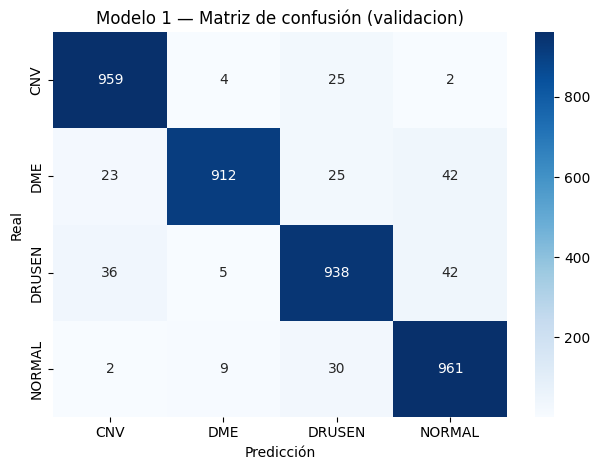

In [13]:
# ── Evaluación en test ─────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los mejores pesos
model_raw.load_state_dict(torch.load(best_path, map_location=device))
model_raw.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        all_preds.extend(model_raw(x).argmax(dim=1).cpu().numpy())
        all_labels.extend(y.numpy())

class_names = ['CNV', 'DME', 'DRUSEN', 'NORMAL']
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Modelo 1 — Matriz de confusión (validacion)')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

# Modelo 2 - Con segmentación

In [14]:
pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.3 MB/s eta 0:00:00


In [15]:
import os
import numpy as np
import kagglehub
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Dataset
import segmentation_models_pytorch as smp
from PIL import Image

In [19]:
if not os.path.exists(output_zip):
    import gdown
    gdown.download(id='1qLXEMAwxmAgUEj6ZXRfra29g3zyf3jVp',
               output='modelos/unetpp_smp_finetunning.pth',
               quiet=False)
else:
    print('Pesos del modelo segmentador ya descargados')


!ls -R /content/modelos

print(os.path.exists("/content/modelos/unetpp_smp_finetunning.pth"))
print(os.path.getsize("/content/modelos/unetpp_smp_finetunning.pth"))

Downloading...
From (original): https://drive.google.com/uc?id=1qLXEMAwxmAgUEj6ZXRfra29g3zyf3jVp
From (redirected): https://drive.google.com/uc?id=1qLXEMAwxmAgUEj6ZXRfra29g3zyf3jVp&confirm=t&uuid=a50d3119-ce13-45e8-90b8-1f5fee71c4d1
To: /content/modelos/unetpp_smp_finetunning.pth
100%|██████████| 105M/105M [00:01<00:00, 78.7MB/s] 


/content/modelos:
modelo_raw_resnet50.pth  unetpp_smp_finetunning.pth
True
104507999


In [20]:
# ── Carga del modelo de segmentación ──────────────────────────────────
# El modelo es UNet++ con encoder ResNet34, 1 canal entrada, 8 clases de salida.
# Guardado con torch.save(model.state_dict(), ...)

seg_model = smp.UnetPlusPlus(
    encoder_name='resnet34',
    encoder_weights=None,   # no cargar imagenet, vamos a cargar nuestros pesos
    in_channels=1,
    classes=8
)


size = os.path.getsize('modelos/unetpp_smp_finetunning.pth')
print(f"{size / 1024 / 1024:.1f} MB")  # debe decir ~99.6 MB

seg_model.load_state_dict(torch.load('/content/modelos/unetpp_smp_finetunning.pth', map_location=device))
seg_model.to(device)
seg_model.eval()

# Congelar: no queremos que se entrene junto con el clasificador
for param in seg_model.parameters():
    param.requires_grad = False

print('Modelo de segmentación cargado y congelado.')

99.7 MB
Modelo de segmentación cargado y congelado.
